<a href="https://colab.research.google.com/github/MeFabiLuz/causal_analysis/blob/main/EBA_01_motivation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# O problema da causalidade

## Objetivos

Ao final deste projeto, será possível:

1. Distinguir perguntas **preditivas** de perguntas **causais**, compreendendo que elas exigem formas diferentes de raciocínio e análise.
2. Reconhecer por que **correlações e modelos preditivos**, mesmo quando bem ajustados, **não são suficientes** para responder perguntas causais.
3. Entender o papel da **inferência causal no suporte à tomada de decisão**, especialmente em contextos que envolvem ações, intervenções ou políticas.
4. Identificar situações práticas em ciência de dados nas quais uma **análise causal é necessária**, ainda que os dados disponíveis sejam observacionais.
5. Compreender o tipo de problema que este livro se propõe a resolver, bem como o **tipo de erro conceitual que ele busca evitar**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
	from ci_book.viz.style import set_plot_style
	set_plot_style()
except:
	pass

np.random.seed(42)

## Motivação

Grande parte do trabalho em ciência de dados consiste em **descrever padrões** e **fazer previsões** a partir de dados históricos. Estimamos probabilidades, treinamos modelos, avaliamos métricas e buscamos melhorar a capacidade de antecipar o que provavelmente irá acontecer.

Esse tipo de análise é extremamente valioso. No entanto, muitos problemas reais não se resumem a prever o futuro — eles exigem **tomar decisões**.

Considere perguntas como:

- Devemos oferecer um desconto a este cliente?
- Essa política pública reduziu a evasão escolar?
- Vale a pena implementar este novo protocolo clínico?
- Essa funcionalidade causou aumento no engajamento dos usuários?

Essas não são perguntas sobre *o que vai acontecer*, mas sobre *o que acontece se fizermos algo*. Em outras palavras, são perguntas sobre **efeitos de ações**.

Uma reação natural diante dessas perguntas é recorrer às ferramentas que já conhecemos: comparar médias, analisar correlações ou treinar modelos preditivos. Se usuários expostos a uma funcionalidade apresentam maior engajamento, ou se pacientes que receberam um tratamento apresentam melhores desfechos, a conclusão parece imediata: a ação funcionou.

O problema é que esse raciocínio, embora intuitivo, pode ser profundamente enganoso.

Diferenças observadas entre grupos podem refletir não apenas o efeito da ação, mas também **diferenças pré-existentes** entre eles. Usuários que adotam uma nova funcionalidade podem ser, desde o início, mais engajados. Pacientes que recebem determinado tratamento podem ser sistematicamente diferentes daqueles que não recebem. Nessas situações, a associação observada nos dados não corresponde necessariamente a um efeito causal.

Modelos preditivos sofisticados não resolvem esse problema por si só. Um modelo pode prever com grande precisão quem terá um determinado desfecho, sem que isso implique qualquer compreensão sobre o impacto de uma intervenção. Métricas como acurácia, AUC ou erro quadrático médio avaliam capacidade preditiva — não validade causal.

A inferência causal surge exatamente nesse ponto: **quando queremos entender o efeito de decisões, intervenções ou políticas**, e não apenas descrever associações nos dados. Seu objetivo não é prever o futuro mais provável, mas responder perguntas do tipo *“o que teria acontecido se tivéssemos agido de forma diferente?”*.

Este livro parte da premissa de que muitas análises falham não por falta de sofisticação técnica, mas por um **desalinhamento entre a pergunta feita e a ferramenta utilizada**. Ao longo dos próximos capítulos, desenvolveremos uma linguagem, um conjunto de conceitos e métodos que permitem formular perguntas causais corretamente e avaliar, com rigor, quando e como elas podem ser respondidas a partir dos dados disponíveis.

## Do argumento abstrato ao problema concreto

Até aqui, discutimos por que perguntas causais não podem ser respondidas apenas com correlações ou modelos preditivos. No entanto, esse tipo de argumento pode parecer abstrato demais à primeira vista.

Afinal, em muitas situações práticas, comparar grupos parece razoável. Se pacientes tratados apresentam melhores desfechos do que pacientes não tratados, por que não concluir que o tratamento funciona? Se usuários expostos a uma funcionalidade se engajam mais, por que não implementá-la para todos?

O problema é que esse tipo de raciocínio ignora um aspecto fundamental dos dados observacionais: **as pessoas que recebem uma intervenção geralmente não são comparáveis às que não recebem**.

Para tornar esse ponto concreto, vamos analisar um exemplo simples, inspirado em aplicações reais na área da saúde. O objetivo não é introduzir métodos ou notação formal, mas mostrar, com dados e visualizações, como conclusões intuitivas podem ser enganosas — mesmo quando parecem respaldadas pelos números.

## Exemplo: um novo tratamento médico

Suponha que um hospital esteja avaliando a eficácia de um novo tratamento médico. O desfecho de interesse é simples: **sobrevivência**. Cada paciente ou sobrevive ou não sobrevive após o tratamento.

O hospital dispõe de dados históricos e observa que pacientes que receberam o novo tratamento apresentam, em média, uma taxa de sobrevivência maior do que aqueles que receberam o tratamento padrão.

À primeira vista, isso parece uma evidência clara de que o novo tratamento é melhor.

Antes de aceitar essa conclusão, vamos olhar os dados com mais cuidado.

In [ ]:
def generate_treatment_data(
    n=4000,
    seed=42,
    # Probabilidades de receber o tratamento por gravidade (seleção)
    # (agora: pacientes graves têm MAIOR chance de receber o novo tratamento)
    p_treat_mild=0.20,
    p_treat_severe=0.80,
    # Proporção de casos graves na população
    p_severe=0.60,
    # Probabilidades de sobreviver por gravidade e tratamento
    # (agora: o tratamento é MELHOR em ambos os estratos)
    p_survive_mild_control=0.70,
    p_survive_mild_treated=0.75,
    p_survive_severe_control=0.20,
    p_survive_severe_treated=0.30,
):
    rng = np.random.default_rng(seed)

    severe = rng.binomial(1, p_severe, size=n).astype(int)  # 1=grave, 0=leve

    p_treat = np.where(severe == 0, p_treat_mild, p_treat_severe)
    treated = rng.binomial(1, p_treat, size=n).astype(int)

    p_survive = np.where(
        severe == 0,
        np.where(treated == 1, p_survive_mild_treated, p_survive_mild_control),
        np.where(treated == 1, p_survive_severe_treated, p_survive_severe_control),
    )
    survived = rng.binomial(1, p_survive, size=n).astype(int)

    df = pd.DataFrame({
        "patient_id": np.arange(1, n + 1),
        "treated": treated,         # T_i
        "survived": survived,       # Y_i
        "severity_hidden": severe,
    })

    return df

df = generate_treatment_data()
df.head()

,patient_id,treated,survived,severity_hidden
0,1,0,1,0
1,2,1,1,1
2,3,1,1,0
3,4,0,1,0
4,5,1,1,1


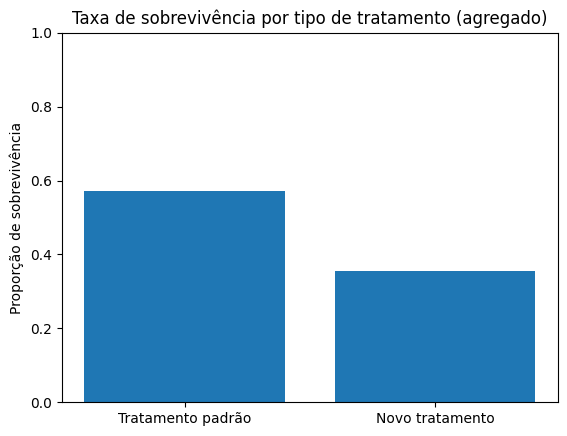

In [ ]:
# Calcula a proporção de sobrevivência por grupo de tratamento
survival_rate = (
    df.groupby("treated")["survived"]
    .mean()
    .reset_index()
)

# Mapeia rótulos mais legíveis
survival_rate["treated_label"] = survival_rate["treated"].map({
    0: "Tratamento padrão",
    1: "Novo tratamento"
})

# Plot
plt.bar(
    survival_rate["treated_label"],
    survival_rate["survived"]
)
plt.ylabel("Proporção de sobrevivência")
plt.title("Taxa de sobrevivência por tipo de tratamento (agregado)")
plt.ylim(0, 1)
plt.show()

## Uma primeira leitura dos dados

A análise agregada sugere que pacientes que receberam o **novo tratamento apresentam uma taxa de sobrevivência menor** do que aqueles que receberam o tratamento padrão.

Se esta fosse a única informação disponível, a conclusão pareceria direta: o novo tratamento seria ineficaz — ou até prejudicial. Em um cenário real, essa evidência poderia levar à sua rejeição imediata.

No entanto, essa conclusão depende implicitamente de uma suposição forte: a de que os grupos “tratado” e “não tratado” são comparáveis em todos os demais aspectos relevantes.

Antes de aceitar essa conclusão, vale questionar se essa suposição é razoável.

## Um fator ignorado: a gravidade dos pacientes

Até aqui, tratamos todos os pacientes como se fossem equivalentes. No entanto, em contextos médicos, isso raramente é verdade.

Pacientes chegam ao hospital em condições muito distintas. Alguns apresentam quadros leves, enquanto outros chegam em estado grave. Essa diferença inicial afeta fortemente a probabilidade de sobrevivência, independentemente do tratamento recebido.

Além disso, decisões médicas costumam levar essas informações em conta. Tratamentos novos ou mais agressivos tendem a ser administrados com maior frequência a pacientes em estado mais grave.

Vamos agora refazer a análise, separando os pacientes de acordo com sua gravidade.

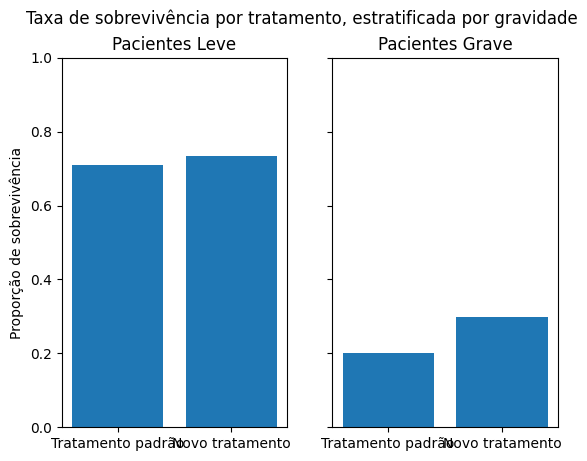

In [ ]:
# Mapeando rótulos para severidade
df["severity_label"] = df["severity_hidden"].map({
    0: "Leve",
    1: "Grave"
})

# Taxa de sobrevivência por tratamento e severidade
survival_by_severity = (
    df.groupby(["severity_label", "treated"])["survived"]
    .mean()
    .reset_index()
)

survival_by_severity["treated_label"] = survival_by_severity["treated"].map({
    0: "Tratamento padrão",
    1: "Novo tratamento"
})

# Plot
fig, axes = plt.subplots(1, 2, sharey=True)

for ax, severity in zip(axes, ["Leve", "Grave"]):
    subset = survival_by_severity[survival_by_severity["severity_label"] == severity]
    ax.bar(
        subset["treated_label"],
        subset["survived"]
    )
    ax.set_title(f"Pacientes {severity}")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Proporção de sobrevivência")
fig.suptitle("Taxa de sobrevivência por tratamento, estratificada por gravidade")
plt.show()

## O que muda quando comparamos pacientes semelhantes

Ao separar os pacientes por nível de gravidade, o padrão observado se inverte completamente.

Tanto entre pacientes com quadros **leves** quanto entre pacientes **graves**, o novo tratamento apresenta uma taxa de sobrevivência **maior** do que o tratamento padrão.

Ou seja, quando comparamos pacientes em condições semelhantes, o tratamento parece ser benéfico em todos os grupos relevantes.

![image.png]()## O Paradoxo de Simpson

Temos agora uma situação aparentemente contraditória:

- No conjunto total dos dados, o novo tratamento parece pior.
- Dentro de cada grupo de gravidade, o novo tratamento parece melhor.

Essa inversão entre a análise agregada e as análises estratificadas é conhecida como **Paradoxo de Simpson**:

![Simpson Paradox](./images/01_motivation_simpson_paradox_example.png)

Retirado de [link](https://epiren.medium.com/when-things-arent-what-they-seem-simpson-s-paradox-d3c3e5fdd6cf).

O paradoxo não é um truque estatístico nem um erro computacional. Ele surge quando grupos comparados diferem sistematicamente em características relevantes que afetam tanto o tratamento quanto o desfecho.

Neste exemplo, a gravidade dos pacientes influencia:
- a probabilidade de receber o tratamento;
- a chance de sobreviver.

Ignorar essa informação leva a uma comparação injusta e a conclusões equivocadas.

Agora que você já conhece o conceito, também pode conhecer o *meme* associado:

![Simpson Paradox Meme](./images/01_motivation_simpson_paradox_meme.jpg)

P.S.: Não, apesar do nome igual o paradoxo não está relacionado ao seriado.

## Por que isso importa

Este exemplo ilustra por que análises baseadas apenas em associações observadas podem ser perigosas quando usadas para orientar decisões.

A pergunta relevante não é simplesmente se pacientes tratados sobrevivem mais, mas **o que teria acontecido com esses mesmos pacientes se tivessem recebido outro tratamento**.

Responder a esse tipo de pergunta exige uma forma diferente de pensar sobre dados, comparações e efeitos — uma forma que será desenvolvida ao longo deste livro.

No próximo capítulo, começaremos a construir essa linguagem formalmente.

## Takeaways

- Perguntas causais são fundamentalmente diferentes de perguntas preditivas.
- Bons modelos preditivos não garantem boas decisões.
- Sempre que uma decisão envolve **agir ou intervir**, a causalidade está em jogo.
- A inferência causal existe para reduzir erros conceituais comuns em análises baseadas apenas em associação.